## PRÁCTICA LOCAL DEPORTIVO - REGRESIÓN

1. Inspección inicial    → ¿qué tengo entre manos?
2. Análisis univariante  → ¿cómo se comporta cada variable por sí sola?
3. Análisis bivariante   → ¿cómo se relaciona cada X con la Y (Gasto)?
4. Matriz de correlación → vista panorámica de todas las relaciones
5. Modelo base (simple)  → empezar con la X que mejor pinta tiene
6. Modelo múltiple       → añadir todas las variables
7. Diagnóstico VIF       → ¿hay variables redundantes entre sí?
8. Análisis de residuos  → ¿el modelo cumple sus supuestos?
9. Decisión final        → qué variables se quedan y por qué

In [1]:
# ============================================
# LIBRERÍAS A USAR
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [2]:
## Cargamos los datos

data = pd.read_excel(r"dataset_didactico_machine_learning - ALUMNOS.xlsx")

#### Inspección inicial

In [3]:
print("--- DIMENSIONES ---")
print("Filas:", data.shape[0], "| Columnas:", data.shape[1])

--- DIMENSIONES ---
Filas: 300 | Columnas: 7


In [4]:
print("\n--- TIPOS DE DATOS ---")
print(data.dtypes)


--- TIPOS DE DATOS ---
ID_Cliente               int64
Antiguedad_Meses         int64
Asistencias_Mes          int64
Horas_Pico_Mes         float64
Gasto_Mensual_Extra    float64
Satisfecho               int64
Abandono                 int64
dtype: object


In [5]:
print("\n--- VALORES NULOS POR COLUMNA ---")
print(data.isnull().sum())


--- VALORES NULOS POR COLUMNA ---
ID_Cliente             0
Antiguedad_Meses       0
Asistencias_Mes        0
Horas_Pico_Mes         0
Gasto_Mensual_Extra    0
Satisfecho             0
Abandono               0
dtype: int64


In [6]:
print("\n--- PRIMERAS FILAS ---")
print(data.head())


--- PRIMERAS FILAS ---
   ID_Cliente  Antiguedad_Meses  Asistencias_Mes  Horas_Pico_Mes  \
0           1                29                1        8.673509   
1           2                15                1        4.396600   
2           3                 8               22       22.313433   
3           4                21               21       20.598791   
4           5                19               18       18.783644   

   Gasto_Mensual_Extra  Satisfecho  Abandono  
0            64.161055           0         1  
1            32.554177           0         0  
2            85.092643           1         0  
3           120.709423           1         0  
4           103.148141           1         0  


In [7]:
print("\n--- RESUMEN ESTADISTICO ---")
print(data.describe().round(2))


--- RESUMEN ESTADISTICO ---
       ID_Cliente  Antiguedad_Meses  Asistencias_Mes  Horas_Pico_Mes  \
count      300.00            300.00           300.00          300.00   
mean       150.50             18.88            12.16           14.67   
std         86.75             10.60             7.27            6.09   
min          1.00              1.00             0.00            1.41   
25%         75.75              9.00             6.00            9.65   
50%        150.50             20.00            12.00           15.07   
75%        225.25             28.00            18.25           19.75   
max        300.00             35.00            24.00           24.00   

       Gasto_Mensual_Extra  Satisfecho  Abandono  
count               300.00      300.00    300.00  
mean                 81.69        0.48      0.16  
std                  30.47        0.50      0.37  
min                  10.00        0.00      0.00  
25%                  61.25        0.00      0.00  
50%             

##### Interpretación de los resultados
- 300 filas y 7 columnas
- Gasto_Mensual_Extra --> rango de 10 a 146. Media de 82. Continua(regresión lineal)
- Antiguedad meses: rango de 1 a 35 meses. Media de 18.8 meses. Distribución uniforme
- Asistencia_Mes: rango de 0 a 24. Media de 12. Hay clientes que no han ido ninguna vez. 
- Horas_Pico_Mes: 1.4 a 24.
- Satisfecho: 48%
- Abandono: 16%

## Paso 2 — Análisis univariante

##### En este paso queremos mirar como se comporta cada variable por separado. 
##### Y queremos responder a las siguientes preguntas:
- ¿Los valores están concentrados en un rango o muy dispersos?
- ¿Hay valores extremos (outliers) que podrían distorsionar el modelo?
- ¿La distribución es simétrica (como una campana) o está sesgada hacia un lado?

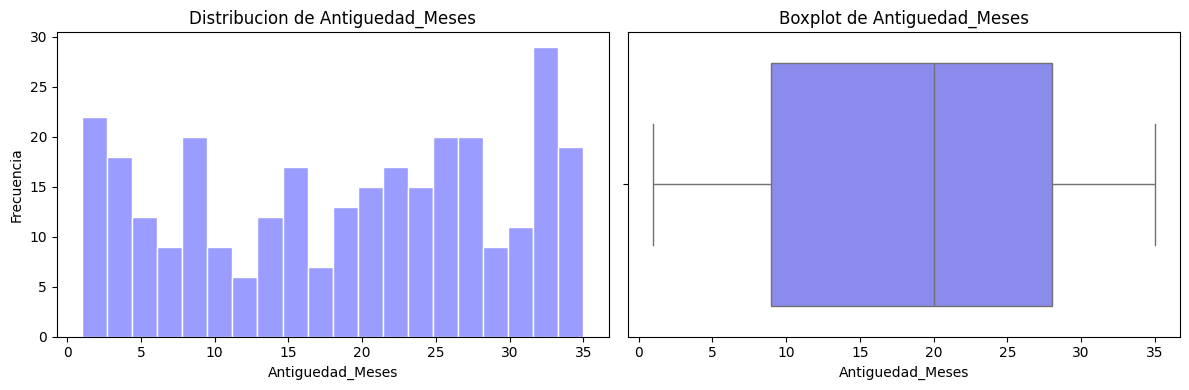

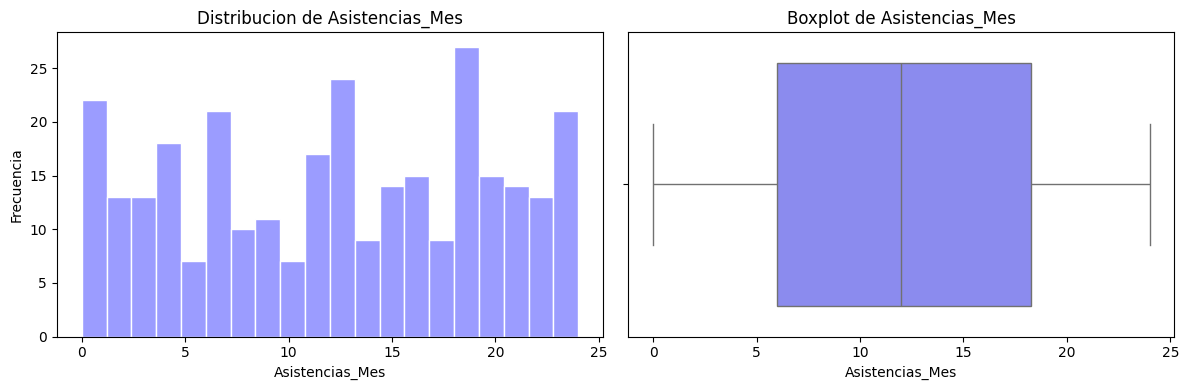

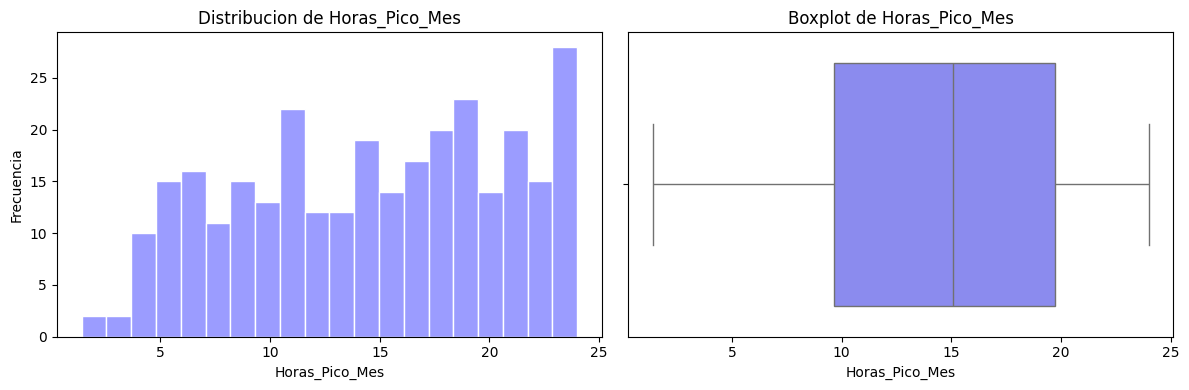

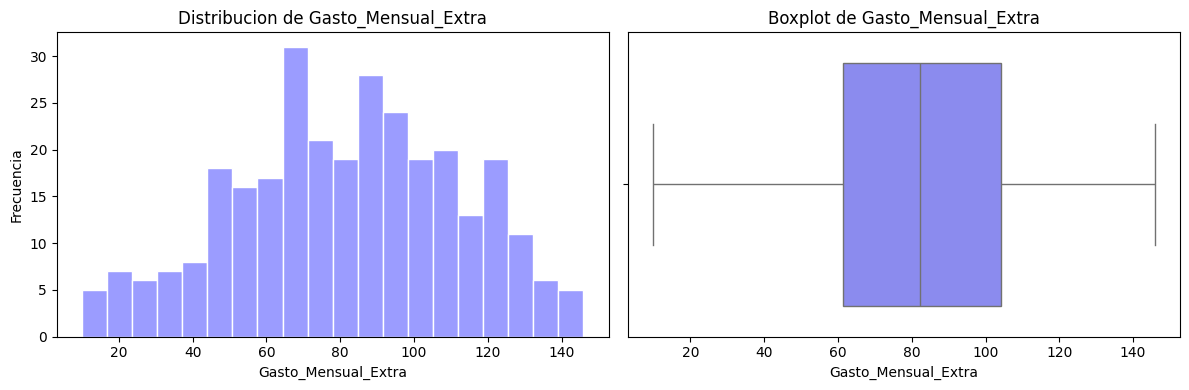


--- CONTEO DE VARIABLES BINARIAS ---

Satisfecho:
Satisfecho
0    156
1    144
Name: count, dtype: int64

Abandono:
Abandono
0    251
1     49
Name: count, dtype: int64


In [8]:
# Variables numericas continuas para analizar
variables_numericas = [
    "Antiguedad_Meses",
    "Asistencias_Mes",
    "Horas_Pico_Mes",
    "Gasto_Mensual_Extra",
]

# Histogramas + boxplots (uno por variable)
for variable in variables_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma
    sns.histplot(data[variable], bins=20, ax=axes[0], color="#7a7bff", edgecolor="white")
    axes[0].set_title("Distribucion de " + variable)
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(x=data[variable], ax=axes[1], color="#7a7bff")
    axes[1].set_title("Boxplot de " + variable)
    axes[1].set_xlabel(variable)

    plt.tight_layout()
    plt.show()

# Variables binarias: conteo
print("\n--- CONTEO DE VARIABLES BINARIAS ---")
print("\nSatisfecho:")
print(data["Satisfecho"].value_counts())
print("\nAbandono:")
print(data["Abandono"].value_counts())

## Paso 3 — Análisis bivariante

##### En esta fase vamos a cruzar las variables contra la variable predictora Y (Gasto_Mensual_Extra).
##### La idea es explicar de un vistazo cuales pueden explicar el gasto y cuales no. 

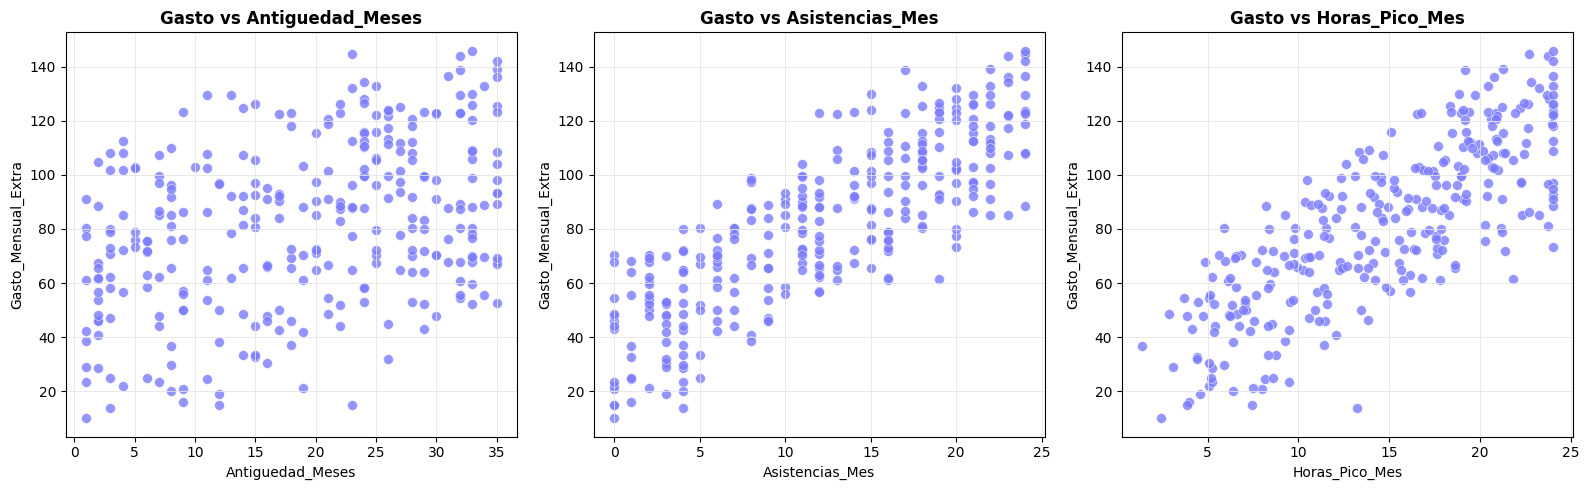

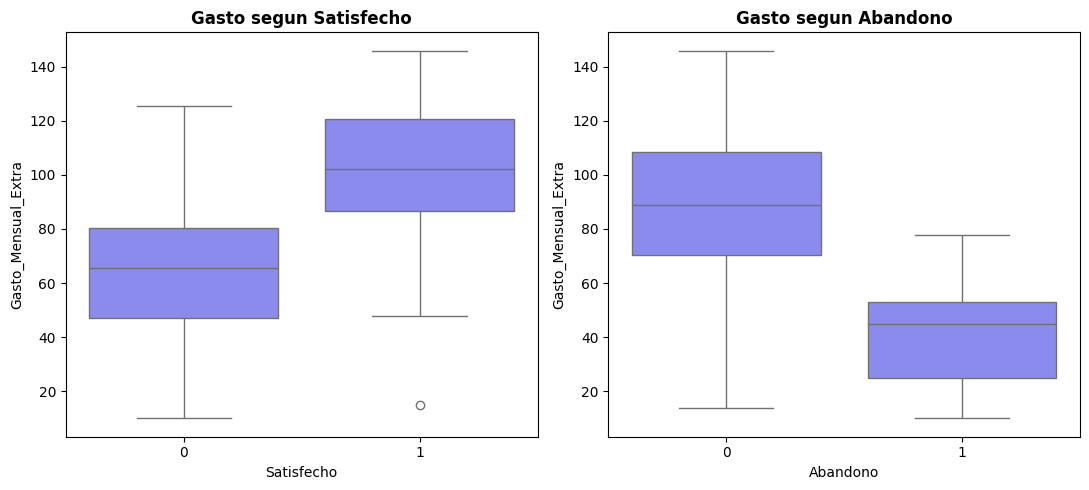

--- CORRELACION CON Gasto_Mensual_Extra ---
Antiguedad_Meses       0.384
Asistencias_Mes        0.824
Horas_Pico_Mes         0.796
Satisfecho             0.623
Abandono              -0.587
Gasto_Mensual_Extra    1.000
Name: Gasto_Mensual_Extra, dtype: float64


In [9]:
# Predictoras numericas vs Gasto (scatterplots)
predictoras_numericas = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, variable in zip(axes, predictoras_numericas):
    ax.scatter(
        data[variable],
        data["Gasto_Mensual_Extra"],
        color="#7a7bff",
        edgecolor="white",
        linewidth=0.4,
        s=50,
        alpha=0.8,
    )
    ax.set_xlabel(variable)
    ax.set_ylabel("Gasto_Mensual_Extra")
    ax.set_title("Gasto vs " + variable, fontweight="bold")
    ax.grid(color="#e5e5e5", linewidth=0.6)
plt.tight_layout()
plt.show()

# Predictoras binarias vs Gasto (boxplots)
predictoras_binarias = ["Satisfecho", "Abandono"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, variable in zip(axes, predictoras_binarias):
    sns.boxplot(x=data[variable], y=data["Gasto_Mensual_Extra"], ax=ax, color="#7a7bff")
    ax.set_title("Gasto segun " + variable, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlacion numerica de cada predictora con la Y
print("--- CORRELACION CON Gasto_Mensual_Extra ---")
columnas_para_correlar = predictoras_numericas + predictoras_binarias + ["Gasto_Mensual_Extra"]
print(data[columnas_para_correlar].corr()["Gasto_Mensual_Extra"].round(3))

#### Conclusiones
- Asistencia_Mes (0.824) --> Nube compacta y ascendente (Candidata fuerte) *
- Horas_Pico_Mes(0.796) --> Nube casi parecida a la anterior *
- Satisfecho (0.623) --> Grupo 1 más arriba que el grupo 0
- Abandono (-0.587) --> si ya se ha ido, gasta menos
- Antiguedad_Meses (0.384) --> Nube con tendencia ascendente, pero mucho más dispersa. Relación débil. 

- Por lo tanto las variables más fuertes son Asistencia_Mes y Horas_Pico_Mes: cuanto más vienes más gastas. 

## Paso 4 — Matriz de correlación

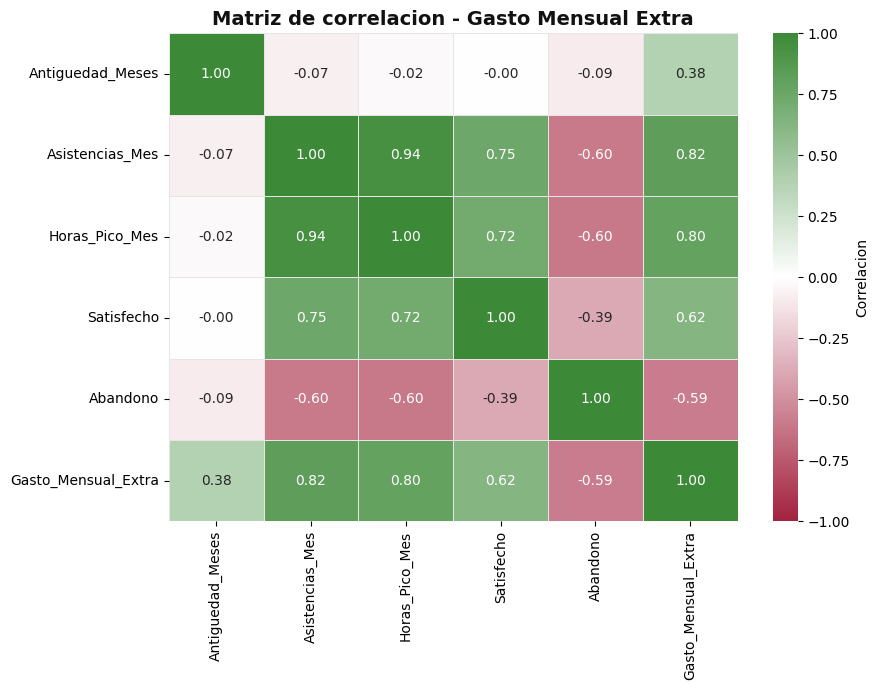

In [10]:
import matplotlib.colors as mcolors

# Variables a incluir (excluimos ID_Cliente: no es informacion, es solo etiqueta)
columnas_modelo = [
    "Antiguedad_Meses",
    "Asistencias_Mes",
    "Horas_Pico_Mes",
    "Satisfecho",
    "Abandono",
    "Gasto_Mensual_Extra",
]

matriz_correlacion = data[columnas_modelo].corr()

# Colormap personalizado: rojo (negativo) - blanco (neutro) - verde (positivo)
cmap_marca = mcolors.LinearSegmentedColormap.from_list(
    "marca_personal", ["#a3223e", "#ffffff", "#3c8a37"]
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap=cmap_marca,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="#e5e5e5",
    cbar_kws={"label": "Correlacion"},
)
plt.title("Matriz de correlacion - Gasto Mensual Extra", fontsize=14, fontweight="bold", color="#111111")
plt.tight_layout()
plt.show()

## Paso 5 — Modelo base (regresión simple)

#### Una sola variable predictora. 
- Asistencia_Mes (r=0.824)

In [11]:
# Modelo de regresion simple: Gasto en funcion de Asistencias_Mes
modelo_simple_cafeteria = ols(
    "Gasto_Mensual_Extra ~ Asistencias_Mes", data=data
).fit()

In [12]:
print("--- RESUMEN DEL MODELO SIMPLE ---")
print(modelo_simple_cafeteria.summary().tables[1])
print("\nR2:", round(modelo_simple_cafeteria.rsquared, 4))
print("R2-ajustado:", round(modelo_simple_cafeteria.rsquared_adj, 4))

--- RESUMEN DEL MODELO SIMPLE ---
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          39.6759      1.948     20.370      0.000      35.843      43.509
Asistencias_Mes     3.4550      0.138     25.117      0.000       3.184       3.726

R2: 0.6792
R2-ajustado: 0.6781


##### Intercept (39.68) representa el gasto base estimado para un cliente con 0 asistencias en el mes (Alguien que paga la cuota pero casi no usa el servicio)

##### Asistencias_Mes (3.4550) por cada asistencia adicional en el mes, el gasto extra sube 3.5 euros | Más visitas, más oportunidad de gastar. 

##### R² = 0.6792 esta variable explica el 68% del gasto. 

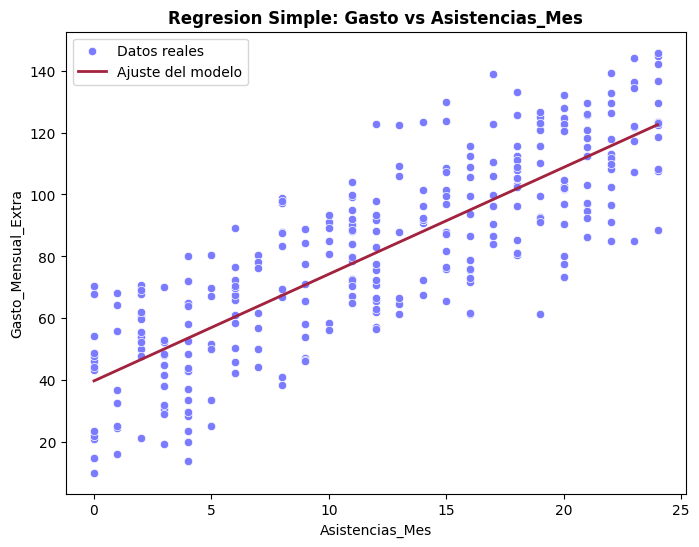

In [13]:
# Visualizar el ajuste
valores_predichos = modelo_simple_cafeteria.fittedvalues

plt.figure(figsize=(8, 6))
sns.scatterplot(x=data["Asistencias_Mes"], y=data["Gasto_Mensual_Extra"],
                color="#7a7bff", label="Datos reales")
sns.lineplot(x=data["Asistencias_Mes"], y=valores_predichos,
             color="#a3223e", linewidth=2, label="Ajuste del modelo")
plt.title("Regresion Simple: Gasto vs Asistencias_Mes", fontweight="bold")
plt.xlabel("Asistencias_Mes")
plt.ylabel("Gasto_Mensual_Extra")
plt.legend()
plt.show()

## Paso 6 — Modelo múltiple

##### Ahora vamos a introducir las 5 variables predictoras a la vez: Antiguedad_Meses, Asistencias_Mes, Horas_Pico_Mes, Satisfecho y Abandono

In [14]:
modelo_multiple_cafeteria = ols(
    "Gasto_Mensual_Extra ~ Antiguedad_Meses + Asistencias_Mes + "
    "Horas_Pico_Mes + Satisfecho + Abandono",
    data=data,
).fit()

print("--- RESUMEN DEL MODELO MULTIPLE ---")
print(modelo_multiple_cafeteria.summary().tables[1])
print("\nR2:", round(modelo_multiple_cafeteria.rsquared, 4))
print("R2-ajustado:", round(modelo_multiple_cafeteria.rsquared_adj, 4))

--- RESUMEN DEL MODELO MULTIPLE ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           16.8864      2.716      6.216      0.000      11.540      22.233
Antiguedad_Meses     1.2691      0.060     21.308      0.000       1.152       1.386
Asistencias_Mes      3.6338      0.274     13.257      0.000       3.094       4.173
Horas_Pico_Mes      -0.1136      0.308     -0.369      0.712      -0.719       0.492
Satisfecho          -1.8807      1.874     -1.003      0.317      -5.570       1.808
Abandono            -4.7466      2.131     -2.228      0.027      -8.940      -0.553

R2: 0.8804
R2-ajustado: 0.8784


##### Observamos lo siguiente:
- Horas_Pico_Mes -> 0.712 DESCARTAMOS | Puede estar muy correlacionada con Asistencias_Mes
- Satisfecho -> 0.317 DESCARTAMOS

## Paso 7 — Diagnóstico VIF

##### Comprobar con numeros si nuestra sospecha sobre Horas_Pico_Mes y Asistencias_Mes es correcta

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

print("--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x = modelo_multiple_cafeteria.model.exog
for i in range(1, matriz_x.shape[1]):
    vif = variance_inflation_factor(matriz_x, i)
    print("Variable", modelo_multiple_cafeteria.model.exog_names[i], ": VIF =", round(vif, 2))

# Determinante de la matriz de correlacion de las 5 predictoras
predictoras = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Satisfecho", "Abandono"]
matriz_corre = data[predictoras].corr()
determinante = np.linalg.det(matriz_corre)
print("\nDeterminante:", round(determinante, 4))

if determinante < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")

# Correlacion directa entre las dos variables sospechosas
print("\nCorrelacion Asistencias_Mes vs Horas_Pico_Mes:")
print(data[["Asistencias_Mes", "Horas_Pico_Mes"]].corr())

--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---
Variable Antiguedad_Meses : VIF = 1.06
Variable Asistencias_Mes : VIF = 10.51
Variable Horas_Pico_Mes : VIF = 9.3
Variable Satisfecho : VIF = 2.33
Variable Abandono : VIF = 1.65

Determinante: 0.0289
Existe cierta multicolinealidad

Correlacion Asistencias_Mes vs Horas_Pico_Mes:
                 Asistencias_Mes  Horas_Pico_Mes
Asistencias_Mes         1.000000        0.942489
Horas_Pico_Mes          0.942489        1.000000


#### Asistencias_Mes y Horas_Pico_Mes tienen una correlación de 0.942 entre sí — prácticamente la misma información contada dos veces.

#### determinante (0.0289) --> esta muy cerca del 0 = multicolinealidad

#### Modelo reducido quitando Horas_Pico_Mes y Satisfecho

In [16]:
modelo_reducido_cafeteria = ols(
    "Gasto_Mensual_Extra ~ Antiguedad_Meses + Asistencias_Mes + Abandono",
    data=data,
).fit()

print("--- RESUMEN DEL MODELO REDUCIDO ---")
print(modelo_reducido_cafeteria.summary().tables[1])
print("\nR2:", round(modelo_reducido_cafeteria.rsquared, 4))
print("R2-ajustado:", round(modelo_reducido_cafeteria.rsquared_adj, 4))

# VIF del modelo reducido (¿se resolvio la colinealidad?)
matriz_x_red = modelo_reducido_cafeteria.model.exog
for i in range(1, matriz_x_red.shape[1]):
    vif = variance_inflation_factor(matriz_x_red, i)
    print("Variable", modelo_reducido_cafeteria.model.exog_names[i], ": VIF =", round(vif, 2))

--- RESUMEN DEL MODELO REDUCIDO ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           16.8382      2.126      7.921      0.000      12.655      21.021
Antiguedad_Meses     1.2607      0.059     21.422      0.000       1.145       1.377
Asistencias_Mes      3.4415      0.106     32.339      0.000       3.232       3.651
Abandono            -4.9019      2.091     -2.344      0.020      -9.018      -0.786

R2: 0.8799
R2-ajustado: 0.8787
Variable Antiguedad_Meses : VIF = 1.03
Variable Asistencias_Mes : VIF = 1.59
Variable Abandono : VIF = 1.59


##### Conclusión
- El R² apenas bajó (0.8804 → 0.8799, solo 0.0005)
- R² ajustado incluso subió ligeramente (0.8784 → 0.8787)

##### Esto es la prueba definitiva: Horas_Pico_Mes y Satisfecho no estaban aportando información real al modelo

##### El VIF del modelo reducido lo remata: bajó de 10.51/9.30 a un cómodo 1.59 — la colinealidad ha quedado completamente resuelta al quitar la variable redundante.

##### las 3 variables que se quedaron tienen ahora p-valores todavía más limpios (Antiguedad_Meses y Asistencias_Mes con p=0.000, Abandono con p=0.020) 

## Paso 9 — Análisis de residuos (modelo reducido)

##### comprobar que los residuos (la diferencia entre lo real y lo predicho)
- ¿Están centrados en 0 y sin patrón? (linealidad bien capturada)
- ¿Su dispersión es constante en todo el rango? (homocedasticidad)
- ¿Se distribuyen aproximadamente como una campana? (normalidad)

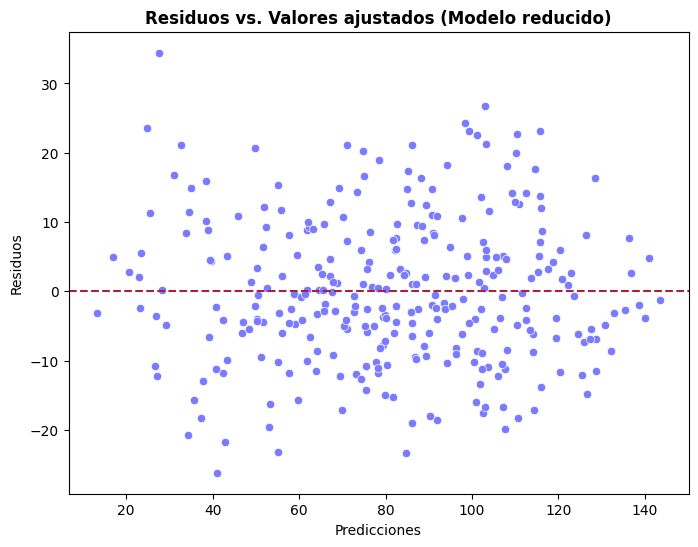

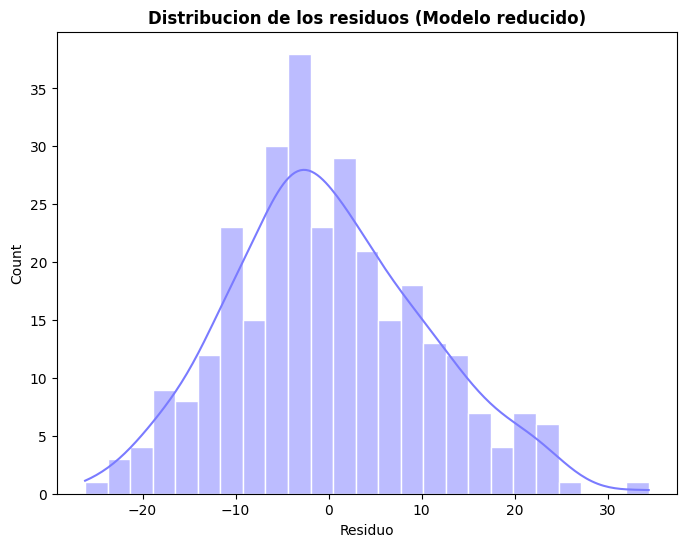

                             OLS Regression Results                            
Dep. Variable:     Gasto_Mensual_Extra   R-squared:                       0.880
Model:                             OLS   Adj. R-squared:                  0.879
Method:                  Least Squares   F-statistic:                     722.9
Date:                 Tue, 30 Jun 2026   Prob (F-statistic):          7.56e-136
Time:                         09:15:31   Log-Likelihood:                -1132.3
No. Observations:                  300   AIC:                             2273.
Df Residuals:                      296   BIC:                             2287.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           16.8382   

In [17]:
valores_ajustados_red = modelo_reducido_cafeteria.fittedvalues
residuos_red = modelo_reducido_cafeteria.resid

# Grafico 1: Residuos vs Valores ajustados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=valores_ajustados_red, y=residuos_red, color="#7a7bff")
plt.axhline(y=0, color="#a3223e", linestyle="--", linewidth=1.5)
plt.title("Residuos vs. Valores ajustados (Modelo reducido)", fontweight="bold")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

# Grafico 2: Distribucion de los residuos (¿forma de campana?)
plt.figure(figsize=(8, 6))
sns.histplot(residuos_red, bins=25, kde=True, color="#7a7bff", edgecolor="white")
plt.title("Distribucion de los residuos (Modelo reducido)", fontweight="bold")
plt.xlabel("Residuo")
plt.show()

# Diagnosticos formales (Omnibus, Jarque-Bera, Durbin-Watson)
print(modelo_reducido_cafeteria.summary())

### Conclusiones
- Gráfico de residuos vs ajustados: la nube está repartida de forma razonablemente simétrica alrededor de la línea roja en 0.
- Histograma de residuos: la forma se aproxima bastante a una campana.

- El modelo final recomendado es: Gasto_Mensual_Extra ~ Antiguedad_Meses + Asistencias_Mes + Abandono, explicando el 87.9% de la variabilidad del gasto

## Paso 10 — Modelo final "seguro para predicción futura" (sin Abandono)

In [18]:
modelo_final_sin_abandono = ols(
    "Gasto_Mensual_Extra ~ Antiguedad_Meses + Asistencias_Mes",
    data=data,
).fit()

print("--- RESUMEN DEL MODELO FINAL (sin Abandono) ---")
print(modelo_final_sin_abandono.summary().tables[1])
print("\nR2:", round(modelo_final_sin_abandono.rsquared, 4))
print("R2-ajustado:", round(modelo_final_sin_abandono.rsquared_adj, 4))

--- RESUMEN DEL MODELO FINAL (sin Abandono) ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           13.7672      1.686      8.163      0.000      10.448      17.086
Antiguedad_Meses     1.2837      0.058     21.954      0.000       1.169       1.399
Asistencias_Mes      3.5925      0.085     42.112      0.000       3.425       3.760

R2: 0.8777
R2-ajustado: 0.8769


### Explica el 87.8% del gasto

## Modelo final: Gasto_Mensual_Extra = 13.77 + 1.28 × Antiguedad_Meses + 3.59 × Asistencias_Mes

## Gasto_Mensual_Extra = 13.77 + 1.28 × Antiguedad_Meses + 3.59 × Asistencias_Mes
         ↑                ↑           ↑                        ↑
    lo que predices   punto de    "precio" de cada         "precio" de cada
                       partida    mes de antigüedad         asistencia extra